# 02b — Audio Exploration (Tier 3)

**Owner:** Audio Lead.
**Role:** Exploratory analysis of the two audio embedding matrices produced by notebook 02. This notebook is **read-only** with respect to the pipeline — it does not modify any `.npy` in `02_Embeddings/` and does not write to `03_Final_Results/`. Safe to re-run, safe to skip.

**Inputs (read-only):**
- `02_Embeddings/audio_ib_embeddings.npy` — `(N, 1024)` ImageBind audio.
- `02_Embeddings/audio_embeddings_MERT.npy` — `(N, 768)` MERT mean-pooled.
- `01_Processed_Data/metadata.csv` — `track_id`, `emotion_category`, …
- `01_Processed_Data/audio/{track_id}.wav` — standardized audio files.

**Outputs:**
- `04_Visual_Checks/02b_{stamp}/spectrogram_gallery.png`
- `04_Visual_Checks/02b_{stamp}/librosa_descriptors.csv`
- `04_Visual_Checks/02b_{stamp}/umap_descriptor_overlay.png`
- `04_Visual_Checks/02b_{stamp}/mert_layer_ablation.csv`
- `04_Visual_Checks/02b_{stamp}/listening_test_pairs.csv`
- `04_Visual_Checks/02b_mert_13layers.npy` — cross-run cache (deletable).

**Read before running:** `audio analysis primer` in notebook 02. Without the primer, the numbers in Cells 8/10 are hard to interpret.

**Runtime:** First run ≈ 5–8 min on a T4 (the 13-layer MERT re-extraction dominates). Subsequent runs ≈ 1–2 min (the cache kicks in).


## How to run

1. Make sure notebook 02 has completed and both `.npy` files are present in `02_Embeddings/`.
2. Run all cells top-to-bottom.
3. After the run:
   - Open `spectrogram_gallery.png` alongside the raw `.wav` files to build intuition.
   - Read `listening_test_pairs.csv` and fill in the empty `your_verdict` column by listening. The filled CSV is the qualitative deliverable for the writeup.
   - Compare the numbers in Cells 8 and 10 against the criteria in the primer (§5).

Delete `04_Visual_Checks/02b_mert_13layers.npy` to force a fresh MERT re-extraction next run.


In [1]:
# === CELL 2: Setup ===
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, sys, random, json, warnings
from datetime import datetime
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# --- Canonical paths (same contract as the pipeline) ---
PROJECT_ROOT  = "/content/drive/MyDrive/DL_Project_2026"
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "01_Processed_Data")
EMBED_DIR     = os.path.join(PROJECT_ROOT, "02_Embeddings")
VIS_DIR       = os.path.join(PROJECT_ROOT, "04_Visual_Checks")

# --- Seed ---
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# --- This notebook's per-run output folder (never shared) ---
NOTEBOOK_ID = "02b"
stamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
OUT_DIR = os.path.join(VIS_DIR, f"{NOTEBOOK_ID}_{stamp}")
os.makedirs(OUT_DIR, exist_ok=True)
print("Outputs →", OUT_DIR)

# --- Cross-run cache for the expensive 13-layer MERT re-extraction ---
LAYERS_CACHE = os.path.join(VIS_DIR, "02b_mert_13layers.npy")
print("Cache path →", LAYERS_CACHE)


Mounted at /content/drive
Device: cuda
Outputs → /content/drive/MyDrive/DL_Project_2026/04_Visual_Checks/02b_2026-04-20_04-56
Cache path → /content/drive/MyDrive/DL_Project_2026/04_Visual_Checks/02b_mert_13layers.npy


In [2]:
# === CELL 3: Install extra dependencies ===
# librosa for audio descriptors + spectrograms
# umap-learn for 2D projections
# transformers + torchaudio for the MERT layer re-extraction
!pip install -q librosa umap-learn
!pip install -q transformers torchaudio

import librosa
import librosa.display
import umap
from sklearn.model_selection    import cross_val_score, StratifiedKFold
from sklearn.linear_model       import LogisticRegression
from sklearn.preprocessing      import StandardScaler, LabelEncoder
from sklearn.pipeline           import Pipeline
from scipy.stats                import spearmanr

print("librosa", librosa.__version__, "| umap-learn", umap.__version__)


librosa 0.11.0 | umap-learn 0.5.12


In [3]:
# === CELL 4: Load (read-only) pipeline artifacts ===
audio_ib_path   = os.path.join(EMBED_DIR, "audio_ib_embeddings.npy")
audio_mert_path = os.path.join(EMBED_DIR, "audio_embeddings_MERT.npy")
meta_path       = os.path.join(PROCESSED_DIR, "metadata.csv")

for p in [audio_ib_path, audio_mert_path, meta_path]:
    assert os.path.exists(p), f"Missing input: {p}. Run notebook 02 first."

audio_ib   = np.load(audio_ib_path)
audio_mert = np.load(audio_mert_path)
metadata   = pd.read_csv(meta_path)

assert audio_ib.shape[1]   == 1024, f"ImageBind audio dim unexpected: {audio_ib.shape}"
assert audio_mert.shape[1] == 768,  f"MERT audio dim unexpected: {audio_mert.shape}"
assert len(audio_ib) == len(audio_mert) == len(metadata), "Row-alignment broken between .npy and metadata"

audio_paths = [os.path.join(PROCESSED_DIR, "audio", f"{tid}.wav") for tid in metadata["track_id"]]

print(f"ImageBind: {audio_ib.shape}   MERT: {audio_mert.shape}")
print(f"{len(metadata)} tracks | {metadata['emotion_category'].nunique()} emotion categories")
print(metadata["emotion_category"].value_counts().to_dict())


ImageBind: (150, 1024)   MERT: (150, 768)
150 tracks | 6 emotion categories
{'Sadness, Loss & Lament': 25, 'Vital & Joyful': 25, 'Tension, Threat & Aggression': 25, 'Dreaminess, Curiosity & Ambiguity': 25, 'Awe, Beauty & Transcendence': 25, 'Tender & Intimacy': 25}


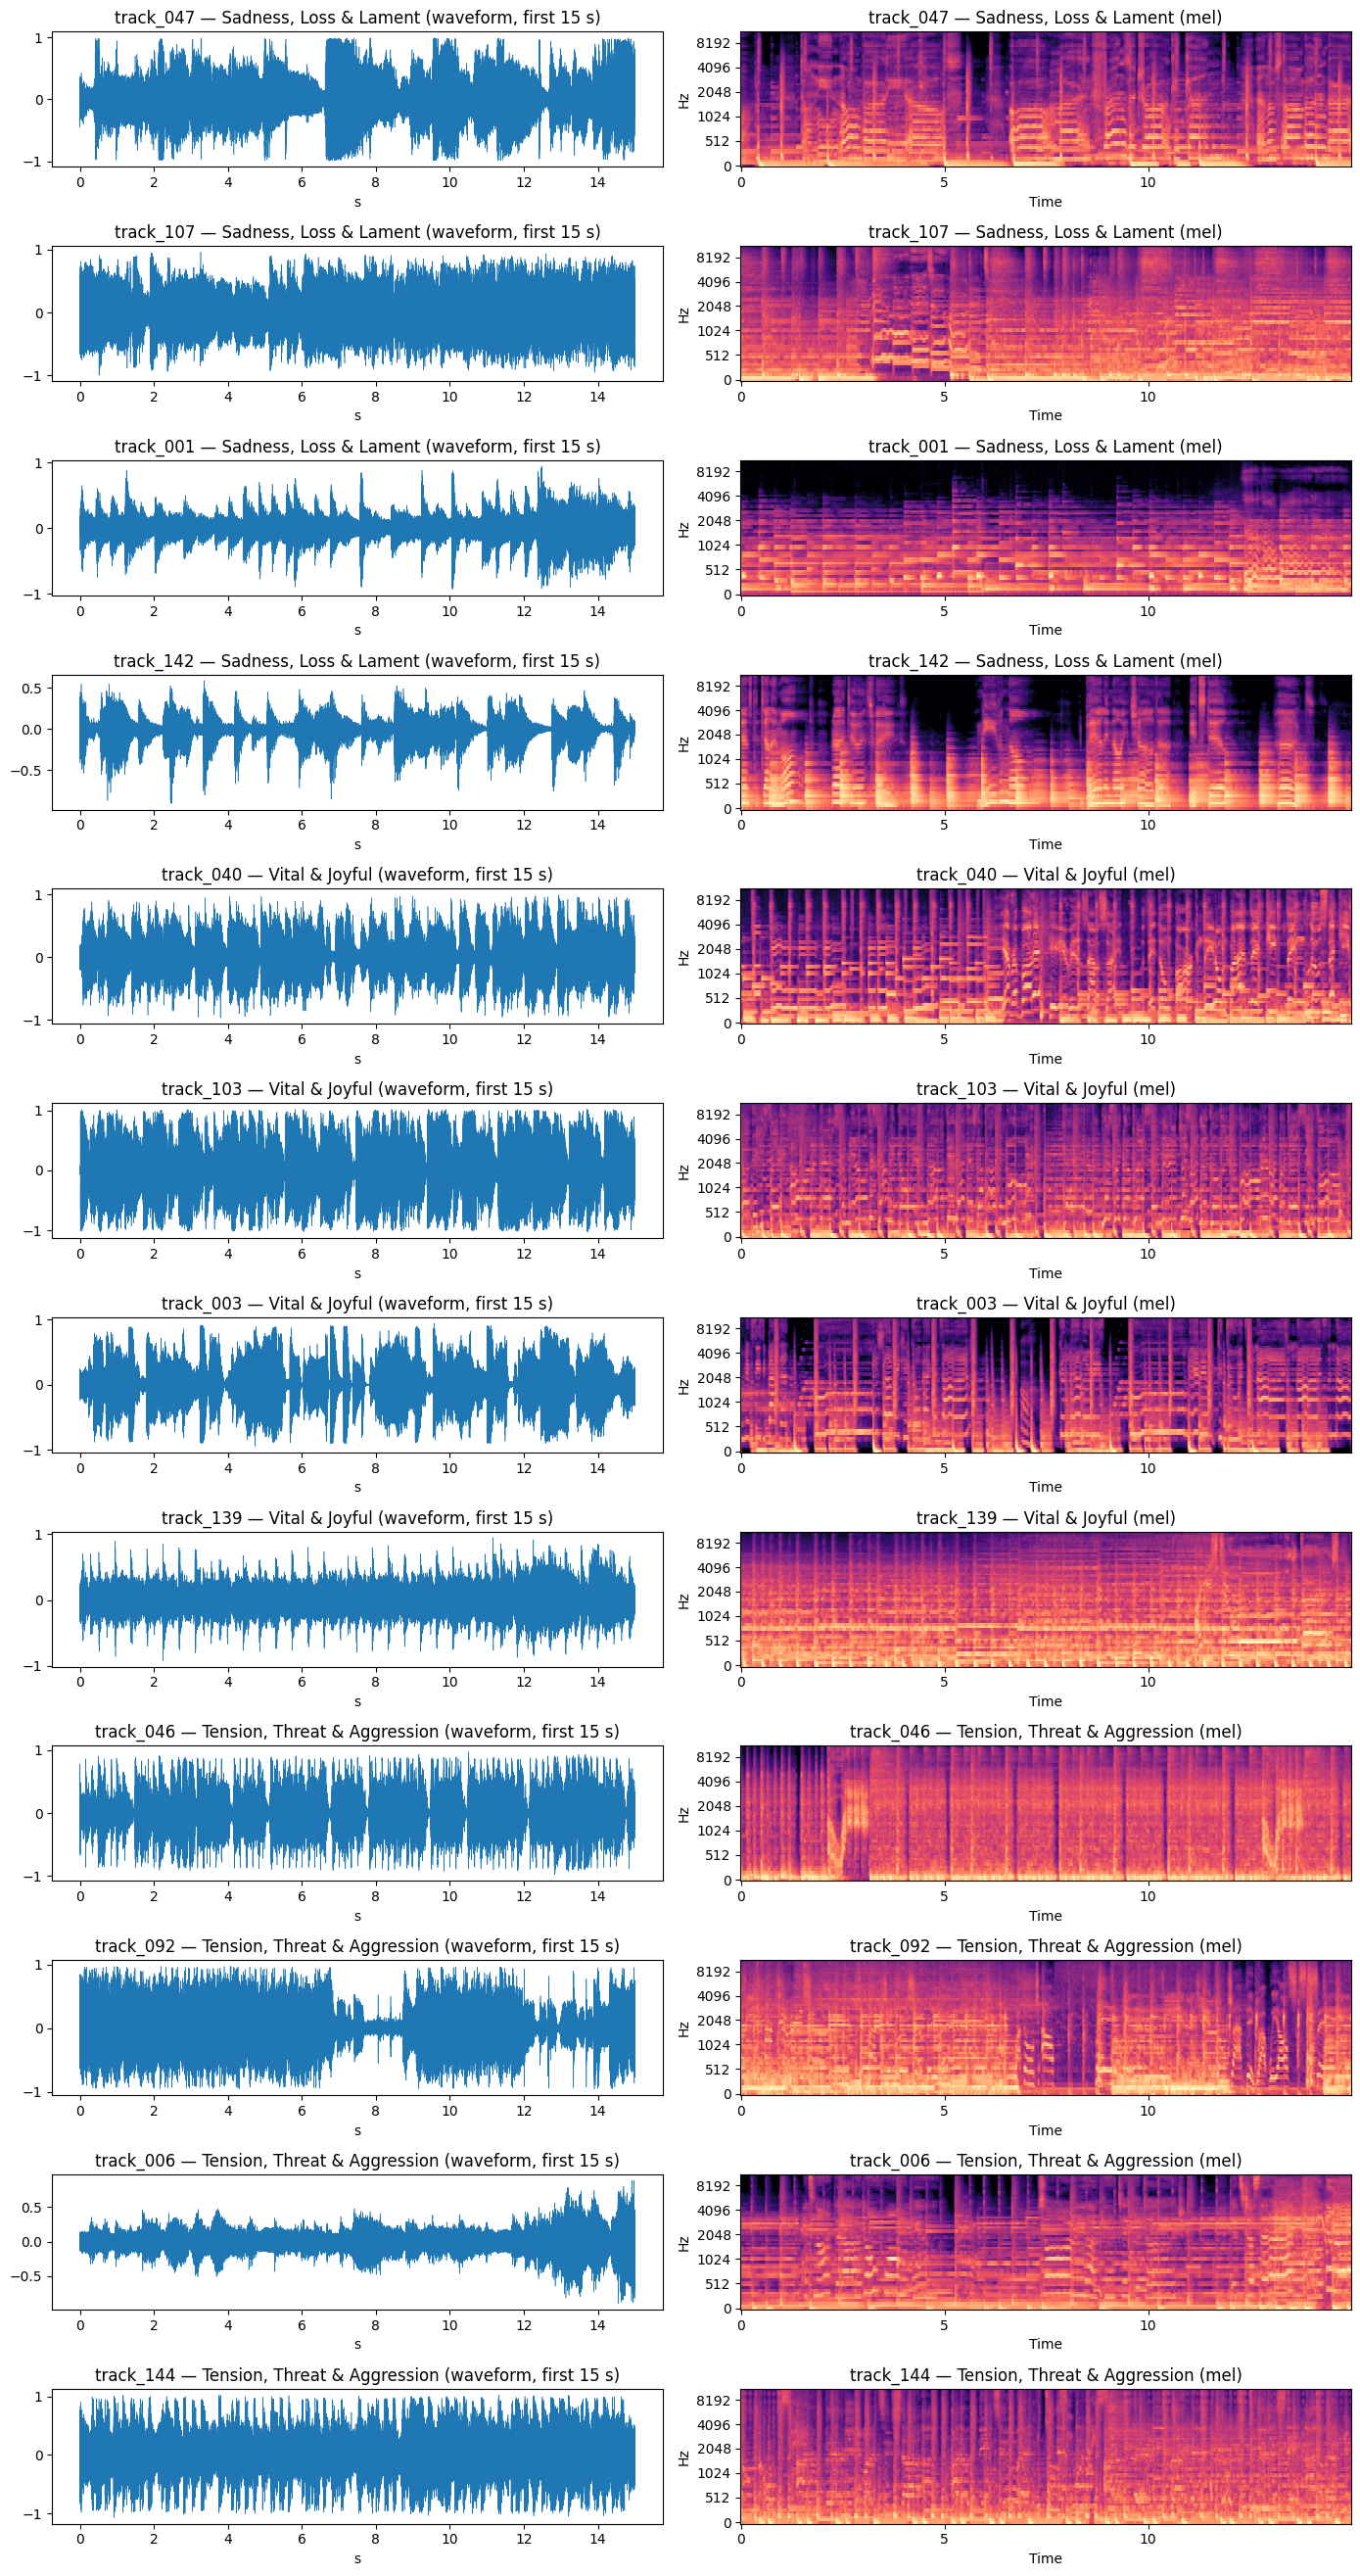

✅ /content/drive/MyDrive/DL_Project_2026/04_Visual_Checks/02b_2026-04-20_04-56/spectrogram_gallery.png


In [4]:
# === CELL 5: Spectrogram + waveform gallery ===
# Stratified sample: 4 tracks each from the 3 most-populated emotion categories.
# Gives the audio lead something acoustic to look at alongside the 768-d vectors.
top_cats = metadata["emotion_category"].value_counts().head(3).index.tolist()
gallery_rows = []
for cat in top_cats:
    pool = metadata[metadata["emotion_category"] == cat]
    picks = pool.sample(n=min(4, len(pool)), random_state=SEED).index.tolist()
    gallery_rows.extend((i, cat) for i in picks)

n_rows = len(gallery_rows)
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 2.2 * n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]
for row, (idx, cat) in enumerate(gallery_rows):
    tid = metadata.iloc[idx]["track_id"]
    y, sr = librosa.load(audio_paths[idx], sr=22050, mono=True, duration=15.0)
    # Waveform
    t = np.linspace(0, len(y) / sr, len(y))
    axes[row, 0].plot(t, y, linewidth=0.4)
    axes[row, 0].set(title=f"{tid} — {cat} (waveform, first 15 s)", xlabel="s")
    # Mel spectrogram
    S   = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    Sdb = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(Sdb, sr=sr, x_axis='time', y_axis='mel', ax=axes[row, 1])
    axes[row, 1].set_title(f"{tid} — {cat} (mel)")
fig.tight_layout()
gallery_path = os.path.join(OUT_DIR, "spectrogram_gallery.png")
fig.savefig(gallery_path, dpi=120)
plt.show()
print(f"✅ {gallery_path}")


In [5]:
# === CELL 6: Librosa descriptor table ===
# Compute musical descriptors for every track. These feed the UMAP overlay
# (Cell 7) and serve as a weak-baseline linear probe (Cell 8).
def compute_descriptors(path):
    y, sr = librosa.load(path, sr=22050, mono=True)
    # tempo: newer librosa exposes this at feature.rhythm.tempo; fall back to beat.tempo
    try:
        tempo = float(librosa.feature.rhythm.tempo(y=y, sr=sr)[0])
    except AttributeError:
        tempo = float(librosa.beat.tempo(y=y, sr=sr)[0])
    rms      = float(np.mean(librosa.feature.rms(y=y)))
    centroid = float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)))
    zcr      = float(np.mean(librosa.feature.zero_crossing_rate(y=y)))
    chroma   = librosa.feature.chroma_stft(y=y, sr=sr).mean(axis=1)
    probs    = chroma / (chroma.sum() + 1e-12)
    chroma_entropy = float(-np.sum(probs * np.log(probs + 1e-12)))
    return tempo, rms, centroid, zcr, chroma_entropy

rows = []
for i, tid in enumerate(metadata["track_id"]):
    tempo, rms, centroid, zcr, chroma_entropy = compute_descriptors(audio_paths[i])
    rows.append((tid, tempo, rms, centroid, zcr, chroma_entropy))

desc_df = pd.DataFrame(rows, columns=["track_id", "tempo_bpm", "rms", "centroid", "zcr", "chroma_entropy"])
desc_df = desc_df.merge(metadata[["track_id", "emotion_category"]], on="track_id")
desc_path = os.path.join(OUT_DIR, "librosa_descriptors.csv")
desc_df.to_csv(desc_path, index=False)

print(f"✅ {desc_path}")
print(desc_df.drop(columns=["track_id", "emotion_category"]).describe().round(2))


✅ /content/drive/MyDrive/DL_Project_2026/04_Visual_Checks/02b_2026-04-20_04-56/librosa_descriptors.csv
       tempo_bpm     rms  centroid     zcr  chroma_entropy
count     150.00  150.00    150.00  150.00          150.00
mean      122.97    0.20   1977.15    0.08            2.45
std        20.49    0.08    629.53    0.03            0.03
min        76.00    0.01    641.60    0.02            2.20
25%       112.35    0.14   1600.33    0.06            2.43
50%       123.05    0.21   2011.62    0.07            2.46
75%       136.00    0.27   2378.79    0.10            2.47
max       184.57    0.39   3713.53    0.17            2.48


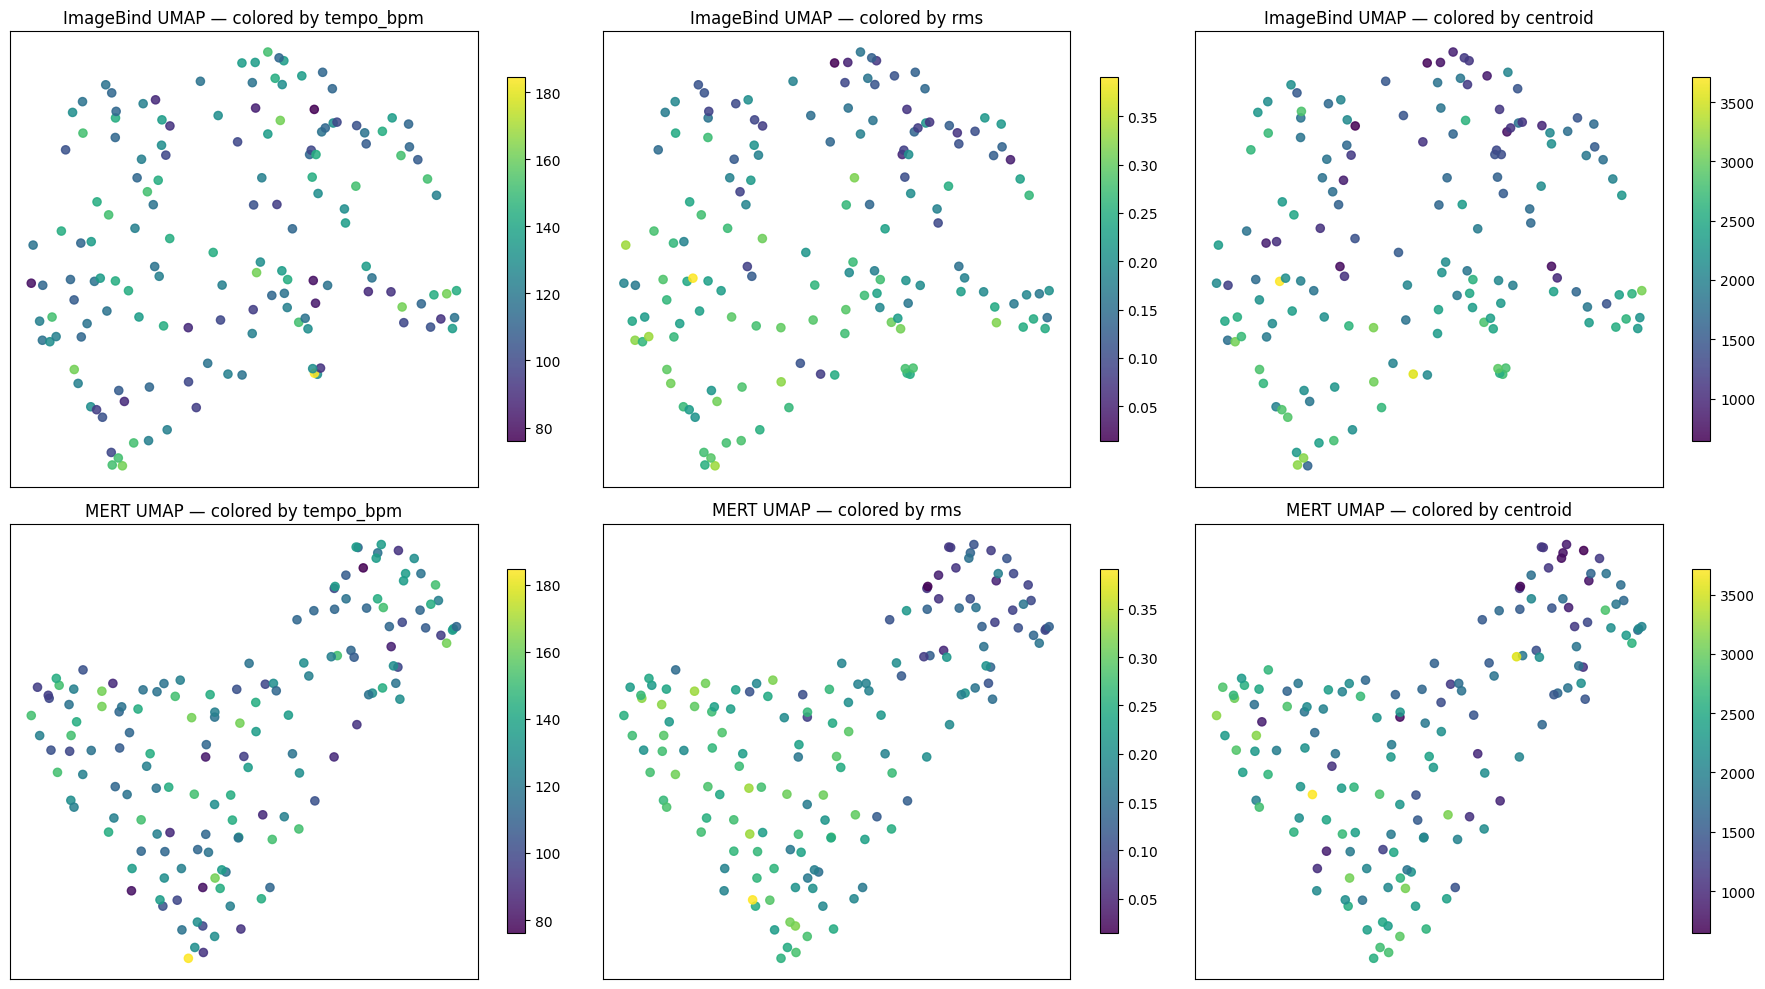

✅ /content/drive/MyDrive/DL_Project_2026/04_Visual_Checks/02b_2026-04-20_04-56/umap_descriptor_overlay.png

Spearman ρ between UMAP-X axis and descriptors:
  ImageBind  UMAP-X × tempo_bpm     : rho=-0.016  p=0.849
  ImageBind  UMAP-X × rms           : rho=-0.303  p=0.000
  ImageBind  UMAP-X × centroid      : rho=-0.162  p=0.048
  MERT       UMAP-X × tempo_bpm     : rho=-0.032  p=0.694
  MERT       UMAP-X × rms           : rho=-0.699  p=0.000
  MERT       UMAP-X × centroid      : rho=-0.479  p=0.000


In [6]:
# === CELL 7: UMAP with descriptor color overlay ===
# Fresh UMAP per encoder (factory pattern). Cosine metric + L2-normalized input
# matches the pipeline's notebook-06 convention.
def l2norm(X):
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)

def make_umap():
    return umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=SEED)

coords_ib   = make_umap().fit_transform(l2norm(audio_ib))
coords_mert = make_umap().fit_transform(l2norm(audio_mert))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for col, d in enumerate(["tempo_bpm", "rms", "centroid"]):
    for row, (name, coords) in enumerate([("ImageBind", coords_ib), ("MERT", coords_mert)]):
        sc = axes[row, col].scatter(coords[:, 0], coords[:, 1],
                                    c=desc_df[d], cmap='viridis', s=35, alpha=0.85)
        axes[row, col].set_title(f"{name} UMAP — colored by {d}")
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
        plt.colorbar(sc, ax=axes[row, col], shrink=0.8)
fig.tight_layout()
umap_path = os.path.join(OUT_DIR, "umap_descriptor_overlay.png")
fig.savefig(umap_path, dpi=120)
plt.show()

print(f"✅ {umap_path}\n")
print("Spearman ρ between UMAP-X axis and descriptors:")
for name, coords in [("ImageBind", coords_ib), ("MERT", coords_mert)]:
    for d in ["tempo_bpm", "rms", "centroid"]:
        rho, p = spearmanr(coords[:, 0], desc_df[d])
        print(f"  {name:10s} UMAP-X × {d:14s}: rho={rho:+.3f}  p={p:.3f}")


In [7]:
# === CELL 8: Linear probe — emotion-category classification ===
# 5-fold StratifiedKFold, macro-F1. Three comparisons:
#   (1) ImageBind audio (1024-d)
#   (2) MERT mean-pooled (768-d) — the pipeline's default
#   (3) Librosa descriptors (5-d) — weak baseline / floor
# Any encoder that fails to beat the 5-d descriptor baseline is not doing work.
y = LabelEncoder().fit_transform(metadata["emotion_category"])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def linear_probe(X, name):
    pipe = Pipeline([
        ("sc", StandardScaler()),
        ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
    ])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
    print(f"  {name:30s} {scores.mean():.3f} ± {scores.std():.3f}")
    return float(scores.mean()), float(scores.std())

print("Linear-probe macro-F1 (5-fold CV):")
ib_mean,    ib_std    = linear_probe(audio_ib,                                                 "ImageBind (1024)")
mert_mean,  mert_std  = linear_probe(audio_mert,                                               "MERT mean-pool (768)")
desc_cols = ["tempo_bpm", "rms", "centroid", "zcr", "chroma_entropy"]
desc_mean, desc_std   = linear_probe(desc_df[desc_cols].values,                                "Librosa descriptors (5)")

# Specialist verdict line
gap = mert_mean - ib_mean
verdict = "MERT > ImageBind (specialist hypothesis holds)" if gap > 0.02 else \
          "within noise — see primer §5 before drawing conclusions"
print(f"\nMERT − ImageBind macro-F1 gap: {gap:+.3f}   → {verdict}")


Linear-probe macro-F1 (5-fold CV):
  ImageBind (1024)               0.284 ± 0.065
  MERT mean-pool (768)           0.240 ± 0.072
  Librosa descriptors (5)        0.227 ± 0.061

MERT − ImageBind macro-F1 gap: -0.044   → within noise — see primer §5 before drawing conclusions


In [8]:
# === CELL 9: MERT 13-layer re-extraction (cached) ===
# Mean-pools over time only; layer axis is preserved.
# Output shape: (N, 13, 768). Written to a cross-run cache so the expensive
# forward pass only happens when the cache is missing. Delete the cache file
# to force a fresh run.
if os.path.exists(LAYERS_CACHE):
    mert_layers = np.load(LAYERS_CACHE)
    # Defensive: verify shape matches current embedding count
    if mert_layers.shape == (len(metadata), 13, 768):
        print(f"✅ Loaded cached layers from {LAYERS_CACHE} | shape={mert_layers.shape}")
    else:
        print(f"⚠️  Cache shape mismatch ({mert_layers.shape} vs expected {(len(metadata), 13, 768)}) — re-extracting")
        os.remove(LAYERS_CACHE)

if not os.path.exists(LAYERS_CACHE):
    from transformers import AutoModel, Wav2Vec2FeatureExtractor
    import torchaudio
    import torchaudio.transforms as T

    mert_model = AutoModel.from_pretrained(
        "m-a-p/MERT-v1-95M", trust_remote_code=True
    ).to(device).eval()
    mert_proc = Wav2Vec2FeatureExtractor.from_pretrained(
        "m-a-p/MERT-v1-95M", trust_remote_code=True
    )
    TARGET_SR = mert_proc.sampling_rate

    resample_cache = {}
    all_layers = []
    for tid in metadata["track_id"]:
        w, sr = torchaudio.load(os.path.join(PROCESSED_DIR, "audio", f"{tid}.wav"))
        if w.shape[0] > 1:
            w = w.mean(dim=0, keepdim=True)
        if sr != TARGET_SR:
            if sr not in resample_cache:
                resample_cache[sr] = T.Resample(sr, TARGET_SR)
            w = resample_cache[sr](w)
        inp = mert_proc(w.squeeze().numpy(), sampling_rate=TARGET_SR, return_tensors="pt")
        inp = {k: v.to(device) for k, v in inp.items()}
        with torch.no_grad():
            out = mert_model(**inp, output_hidden_states=True)
        # (13, T, 768) → mean over time → (13, 768)
        stacked = torch.stack(out.hidden_states).squeeze(1).mean(dim=1)
        all_layers.append(stacked.cpu().numpy().astype(np.float32))
    mert_layers = np.stack(all_layers, axis=0)  # (N, 13, 768)
    np.save(LAYERS_CACHE, mert_layers)
    print(f"✅ Extracted + cached layers: {LAYERS_CACHE} | shape={mert_layers.shape}")


config.json: 0.00B [00:00, ?B/s]

configuration_MERT.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/m-a-p/MERT-v1-95M:
- configuration_MERT.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_MERT.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/m-a-p/MERT-v1-95M:
- modeling_MERT.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

✅ Extracted + cached layers: /content/drive/MyDrive/DL_Project_2026/04_Visual_Checks/02b_mert_13layers.npy | shape=(150, 13, 768)


MERT layer-pooling ablation — 5-fold macro-F1:
  mean(all 13)                   0.240 ± 0.072
  last layer (12)                0.216 ± 0.049
  layer 9                        0.247 ± 0.069
  layer 6 (middle)               0.301 ± 0.061
  layer 3 (early)                0.214 ± 0.030
  late3 mean(10,11,12)           0.225 ± 0.039
  concat(6,12)                   0.266 ± 0.063

✅ /content/drive/MyDrive/DL_Project_2026/04_Visual_Checks/02b_2026-04-20_04-56/mert_layer_ablation.csv
             pooling  dim  f1_macro_mean  f1_macro_std
    layer 6 (middle)  768       0.301337      0.060944
        concat(6,12) 1536       0.266147      0.063358
             layer 9  768       0.246947      0.069239
        mean(all 13)  768       0.239857      0.071695
late3 mean(10,11,12)  768       0.224530      0.039080
     last layer (12)  768       0.215764      0.048881
     layer 3 (early)  768       0.213682      0.030342


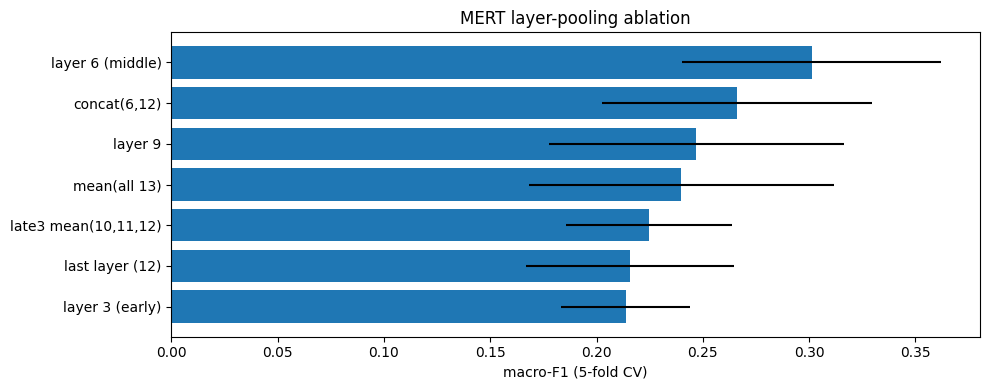

In [9]:
# === CELL 10: MERT layer-pooling ablation ===
# Compare 6 pooling strategies via the same 5-fold linear probe.
# Goal: beat `mean(all 13)` (the pipeline default). If a simpler pooling wins,
# that's evidence we should update the extractor in notebook 02.
pooling_variants = {
    "mean(all 13)":      mert_layers.mean(axis=1),
    "last layer (12)":   mert_layers[:, 12, :],
    "layer 9":           mert_layers[:,  9, :],
    "layer 6 (middle)":  mert_layers[:,  6, :],
    "layer 3 (early)":   mert_layers[:,  3, :],
    "late3 mean(10,11,12)": mert_layers[:, 10:13, :].mean(axis=1),
    "concat(6,12)":      np.concatenate([mert_layers[:, 6, :], mert_layers[:, 12, :]], axis=1),
}

print("MERT layer-pooling ablation — 5-fold macro-F1:")
ablation_rows = []
for name, X in pooling_variants.items():
    mean, std = linear_probe(X, name)
    ablation_rows.append({"pooling": name, "dim": X.shape[1], "f1_macro_mean": mean, "f1_macro_std": std})

ablation_df = pd.DataFrame(ablation_rows).sort_values("f1_macro_mean", ascending=False)
ablation_path = os.path.join(OUT_DIR, "mert_layer_ablation.csv")
ablation_df.to_csv(ablation_path, index=False)
print(f"\n✅ {ablation_path}")
print(ablation_df.to_string(index=False))

# Quick plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(ablation_df["pooling"], ablation_df["f1_macro_mean"], xerr=ablation_df["f1_macro_std"])
ax.set(xlabel="macro-F1 (5-fold CV)", title="MERT layer-pooling ablation")
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "mert_layer_ablation.png"), dpi=120)
plt.show()


In [10]:
# === CELL 11: Listening-test disagreement pairs ===
# For each query track, find its top-1 nearest neighbor in each encoder's space.
# Flag the cases where ImageBind and MERT disagree. Sort by how strongly each
# encoder is confident in its own pick. Top-10 → CSV for human listening review.
ib_n   = l2norm(audio_ib)
mert_n = l2norm(audio_mert)
sim_ib   = ib_n   @ ib_n.T
sim_mert = mert_n @ mert_n.T
np.fill_diagonal(sim_ib,   -np.inf)
np.fill_diagonal(sim_mert, -np.inf)

nn_ib   = np.argmax(sim_ib,   axis=1)
nn_mert = np.argmax(sim_mert, axis=1)

pair_rows = []
for i in range(len(metadata)):
    if nn_ib[i] == nn_mert[i]:
        continue  # agreement — skip
    pair_rows.append({
        "query_id":     metadata.iloc[i]["track_id"],
        "query_cat":    metadata.iloc[i]["emotion_category"],
        "ib_nn_id":     metadata.iloc[nn_ib[i]]["track_id"],
        "ib_nn_cat":    metadata.iloc[nn_ib[i]]["emotion_category"],
        "ib_sim":       float(sim_ib[i, nn_ib[i]]),
        "mert_nn_id":   metadata.iloc[nn_mert[i]]["track_id"],
        "mert_nn_cat":  metadata.iloc[nn_mert[i]]["emotion_category"],
        "mert_sim":     float(sim_mert[i, nn_mert[i]]),
        "confidence_sum": float(sim_ib[i, nn_ib[i]] + sim_mert[i, nn_mert[i]]),
        "which_is_better": "",   # fill in by listening: "ib" / "mert" / "tie" / "both_bad"
        "notes":        "",
    })
pairs_df = (pd.DataFrame(pair_rows)
              .sort_values("confidence_sum", ascending=False)
              .head(10)
              .reset_index(drop=True))
pairs_path = os.path.join(OUT_DIR, "listening_test_pairs.csv")
pairs_df.to_csv(pairs_path, index=False)

print(f"✅ Top-10 disagreement pairs → {pairs_path}")
print("(open the CSV, listen to query / ib_nn / mert_nn for each row, fill in which_is_better)\n")
print(pairs_df[["query_id", "query_cat", "ib_nn_id", "ib_nn_cat", "mert_nn_id", "mert_nn_cat"]].to_string(index=False))


✅ Top-10 disagreement pairs → /content/drive/MyDrive/DL_Project_2026/04_Visual_Checks/02b_2026-04-20_04-56/listening_test_pairs.csv
(open the CSV, listen to query / ib_nn / mert_nn for each row, fill in which_is_better)

 query_id                    query_cat  ib_nn_id                    ib_nn_cat mert_nn_id                       mert_nn_cat
track_067 Tension, Threat & Aggression track_075               Vital & Joyful  track_031                    Vital & Joyful
track_075               Vital & Joyful track_067 Tension, Threat & Aggression  track_047            Sadness, Loss & Lament
track_088 Tension, Threat & Aggression track_075               Vital & Joyful  track_108 Dreaminess, Curiosity & Ambiguity
track_071            Tender & Intimacy track_070       Sadness, Loss & Lament  track_073                 Tender & Intimacy
track_002       Sadness, Loss & Lament track_035            Tender & Intimacy  track_135            Sadness, Loss & Lament
track_091  Awe, Beauty & Transcendence tr

## What to report back

Bring these four numbers / artifacts to the next sync:

1. **MERT − ImageBind macro-F1 gap** (Cell 8). Positive ≥ 0.02 = specialist hypothesis holds. Near zero or negative = needs either Tier-3 findings or a caveat in the writeup.
2. **Best layer-pooling variant from Cell 10.** If a simpler single-layer or late-3 pooling beats `mean(all 13)` by ≥ 0.02 F1, propose updating notebook 02's extractor.
3. **Filled `listening_test_pairs.csv`.** The `which_is_better` column, after you listen, is the qualitative deliverable that makes the writeup publishable.
4. **UMAP-descriptor correlations (Cell 7).** If one UMAP axis correlates > 0.5 with tempo or centroid, that's the "here's what the axes mean" finding — report it.

Don't spend more than ~3 hours on this notebook. It's exploratory — the goal is enough evidence to confirm or deny the specialist hypothesis on the audio arm, not an exhaustive ablation.
